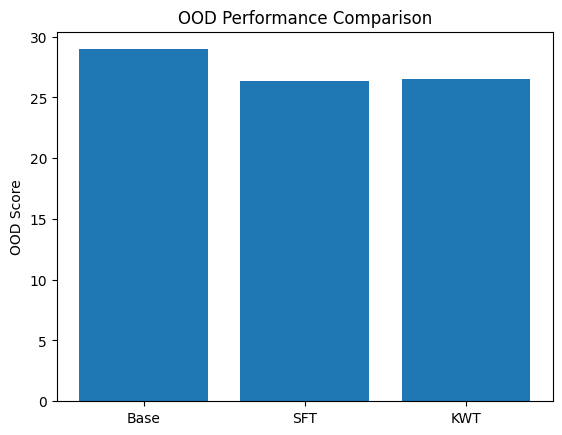

In [1]:
import matplotlib.pyplot as plt

# Data
models = ["Base", "SFT", "KWT"]
scores = [28.955, 26.33, 26.475]

# Plot
plt.figure()
plt.bar(models, scores)
plt.ylabel("OOD Score")
plt.title("OOD Performance Comparison")

plt.show()


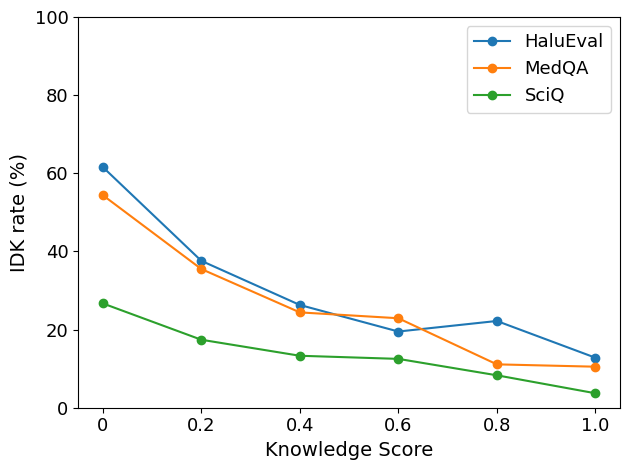

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Input: Base knowledge bins
# -----------------------------
bins = ["0", "0.2", "0.4", "0.6", "0.8", "1.0"]
x = np.arange(len(bins))

# -----------------------------
# IDK Rate (%) from tables
# -----------------------------
idk_halueval = np.array([61.6, 37.6, 26.3, 19.5, 22.2, 12.8])
idk_medqa    = np.array([54.4, 35.5, 24.4, 22.9, 11.1, 10.5])
idk_sciq     = np.array([26.7, 17.4, 13.3, 12.5, 8.3, 3.7])

# -----------------------------
# Plot
# -----------------------------
plt.figure()

plt.plot(x, idk_halueval, marker="o", label="HaluEval")
plt.plot(x, idk_medqa, marker="o", label="MedQA")
plt.plot(x, idk_sciq, marker="o", label="SciQ")

# tick labels
plt.xticks(x, bins, fontsize=13)
plt.yticks(fontsize=13)

plt.ylim(0, 100)

# axis labels
plt.xlabel("Knowledge Score", fontsize=14)
plt.ylabel("IDK rate (%)", fontsize=14)

# legend
plt.legend(fontsize=13)

plt.tight_layout()
plt.savefig("figure/kwt_test_case.pdf", format="pdf", bbox_inches="tight")
plt.show()


/tmp/ipykernel_38027/1558757980.py:61: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  p_auc = np.trapz(y, alpha_sub)


 Dataset      Model  pAUC_[0,0.5]  pAUCnorm_[0,0.5]
HaluEval      KWT+k          38.4              76.7
HaluEval      KWT-U          18.4              36.8
HaluEval     KWT-RF          18.2              36.5
HaluEval   KWT(LLM)          18.1              36.2
HaluEval    KWT(EM)          17.8              35.6
HaluEval KWT(Rouge)          17.4              34.7
HaluEval       SEAL          17.1              34.2
HaluEval   R-Tuning          15.4              30.7
   MedQA     KWT-RF          12.8              25.5
   MedQA      KWT-U          12.8              25.6
   MedQA   KWT(LLM)          12.5              24.9
   MedQA       SEAL          12.5              25.0
   MedQA    KWT(EM)          11.7              23.4
   MedQA KWT(Rouge)          11.4              22.8
   MedQA   R-Tuning          11.4              22.9
    SciQ      KWT+k          39.8              79.6
    SciQ       SEAL          31.7              63.4
    SciQ      KWT-U          31.6              63.2
    SciQ   K

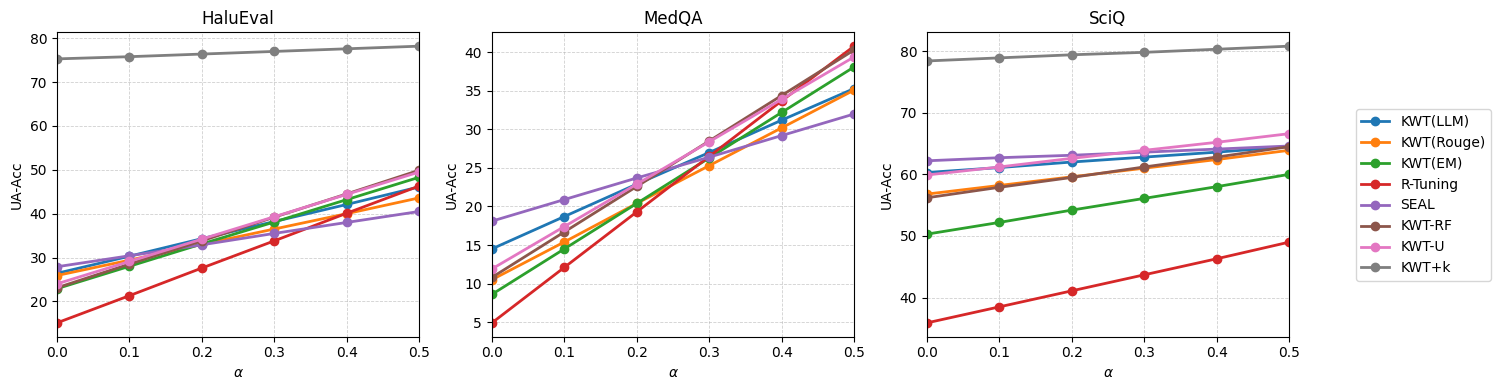

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

alpha = np.array([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

data = {
    "HaluEval": {
        "KWT(LLM)":   [26.4, 30.3, 34.3, 38.2, 42.1, 46.1, 50.0, 53.9, 57.9, 61.8, 65.8],
        "KWT(Rouge)": [25.9, 29.4, 33.0, 36.5, 40.0, 43.6, 47.1, 50.6, 54.2, 57.7, 61.3],
        "KWT(EM)":    [22.9, 28.0, 33.1, 38.1, 43.2, 48.3, 53.4, 58.4, 63.5, 68.6, 73.7],
        "R-Tuning":   [15.1, 21.3, 27.6, 33.8, 40.1, 46.3, 52.5, 58.8, 65.0, 71.3, 77.5],
        "SEAL":       [27.9, 30.4, 32.9, 35.5, 38.0, 40.5, 43.0, 45.5, 48.1, 50.6, 53.1],
        "KWT-RF":     [23.1, 28.5, 33.8, 39.2, 44.5, 49.9, 55.2, 60.6, 65.9, 71.3, 76.7],
        "KWT-U":      [24.0, 29.1, 34.2, 39.3, 44.4, 49.5, 54.5, 59.6, 64.7, 69.8, 74.9],
        # ---- add KWT+k (available only for HaluEval) ----
        "KWT+k":      [75.3, 75.8, 76.4, 77.0, 77.6, 78.2, 78.8, 79.4, 80.0, 80.6, 81.2],
    },
    "MedQA": {
        "KWT(LLM)":   [14.5, 18.7, 22.9, 27.0, 31.2, 35.3, 39.5, 43.7, 47.8, 52.0, 56.2],
        "KWT(Rouge)": [10.5, 15.4, 20.4, 25.3, 30.2, 35.1, 40, 44.9, 49.9, 54.8, 59.7],
        # "KWT(Rouge)": [9.5, 14.6, 19.7, 24.8, 29.9, 35, 40, 45.1, 50.2, 55.3, 60.4],        
        "KWT(EM)":    [8.6, 14.5, 20.4, 26.3, 32.2, 38.1, 44.0, 49.9, 55.8, 61.7, 67.6],
        "R-Tuning":   [4.9, 12.1, 19.3, 26.5, 33.7, 40.8, 48.0, 55.2, 62.4, 69.6, 76.8],
        "SEAL":       [18.1, 20.9, 23.7, 26.4, 29.2, 32.0, 34.7, 37.5, 40.3, 43.0, 45.8],
        "KWT-RF":     [10.8, 16.7, 22.6, 28.5, 34.4, 40.3, 46.2, 52.1, 58.0, 63.9, 69.8],
        "KWT-U":      [11.9, 17.4, 22.9, 28.4, 33.9, 39.4, 44.8, 50.3, 55.8, 61.3, 66.8],
        # ---- no KWT+k for MedQA ----
    },
    "SciQ": {
        "KWT(LLM)":   [60.3, 61.1, 62.0, 62.8, 63.6, 64.5, 65.3, 66.1, 66.9, 67.8, 68.6],
        "KWT(Rouge)": [56.8, 58.2, 59.6, 61, 62.4, 63.9, 65.3, 66.7, 68.1, 69.5, 70.9],
        "KWT(EM)":    [50.3, 52.2, 54.2, 56.1, 58.0, 60.0, 61.9, 63.8, 65.7, 67.7, 69.6],
        "R-Tuning":   [35.9, 38.5, 41.1, 43.7, 46.3, 49.0, 51.6, 54.2, 56.8, 59.4, 62.0],
        "SEAL":       [62.2, 62.7, 63.1, 63.6, 64.1, 64.6, 65.0, 65.5, 66.0, 66.4, 66.9],
        "KWT-RF":     [56.2, 57.9, 59.5, 61.2, 62.8, 64.5, 66.2, 67.8, 69.5, 71.1, 72.8],
        "KWT-U":      [59.9, 61.2, 62.6, 63.9, 65.2, 66.6, 67.9, 69.2, 70.5, 71.9, 73.2],
        # ---- add KWT+k (available only for SciQ) ----
        "KWT+k":      [78.4, 78.9, 79.4, 79.8, 80.3, 80.8, 81.3, 81.8, 82.2, 82.7, 83.2],
    }
}

# "global" method order for plotting/printing; per-dataset filtering will be applied
methods_order = [
    "KWT(LLM)", "KWT(Rouge)", "KWT(EM)",
    "R-Tuning", "SEAL", "KWT-RF", "KWT-U", "KWT+k"
]

# ---- choose alpha range [0, 0.5] ----
a_min, a_max = 0.0, 0.5
mask_auc = (alpha >= a_min) & (alpha <= a_max)
alpha_sub = alpha[mask_auc]
range_len = a_max - a_min

rows = []
for ds, d in data.items():
    # only keep methods that exist in this dataset
    methods = [m for m in methods_order if m in d]
    for m in methods:
        y = np.array(d[m], dtype=float)[mask_auc]
        p_auc = np.trapz(y, alpha_sub)
        p_auc_norm = p_auc / range_len
        rows.append([ds, m, p_auc, p_auc_norm])

df = pd.DataFrame(rows, columns=["Dataset", "Model", "pAUC_[0,0.5]", "pAUCnorm_[0,0.5]"])

# ---- round to 1 decimal ----
df["pAUC_[0,0.5]"] = df["pAUC_[0,0.5]"].round(1)
df["pAUCnorm_[0,0.5]"] = df["pAUCnorm_[0,0.5]"].round(1)

df = df.sort_values(["Dataset", "pAUC_[0,0.5]"], ascending=[True, False]).reset_index(drop=True)
print(df.to_string(index=False))

# -----------------------------
# Plot up to alpha_max
# -----------------------------
alpha_max = 0.5
mask_plot = alpha <= alpha_max
alpha_plot = alpha[mask_plot]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=False)

for ax, (dataset, d) in zip(axes, data.items()):
    methods = [m for m in methods_order if m in d]  # per-dataset
    for m in methods:
        y = np.array(d[m], dtype=float)[mask_plot]
        ax.plot(alpha_plot, y, marker='o', linewidth=2, label=m)

    ax.set_title(dataset)
    ax.set_xlabel(r'$\alpha$')
    ax.set_ylabel('UA-Acc')
    ax.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
    ax.set_xticks(alpha_plot)
    ax.set_xlim(0, alpha_max)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', frameon=True)
fig.tight_layout(rect=[0, 0, 0.88, 1])

plt.show()


  Dataset      Model  pAUC_[0,0.5]  pAUCnorm_[0,0.5]
   RefuNQ KWT(Rouge)        14.275             28.55
   RefuNQ   KWT(LLM)        14.020             28.04
   RefuNQ    KWT(EM)        13.075             26.15
   RefuNQ       SEAL        12.085             24.17
   RefuNQ   R-Tuning        11.910             23.82
SelfAware   KWT(LLM)        17.385             34.77
SelfAware       SEAL        16.900             33.80
SelfAware KWT(Rouge)        16.670             33.34
SelfAware    KWT(EM)        15.975             31.95
SelfAware   R-Tuning        12.675             25.35


/tmp/ipykernel_38027/3631416195.py:43: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  p_auc = np.trapz(y, alpha_sub)


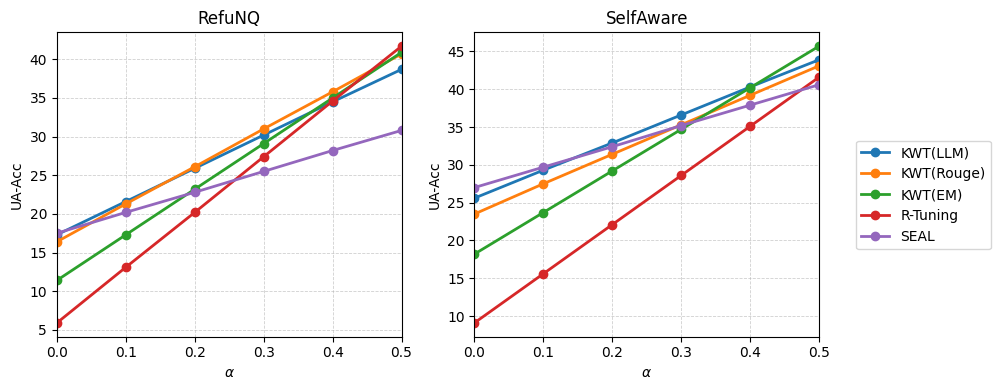

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

alpha = np.array([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

# -----------------------------
# Replace with OOD datasets
# -----------------------------
data = {
    "RefuNQ": {
        "KWT(LLM)":   [17.3, 21.6, 25.9, 30.2, 34.5, 38.7, 43.0, 47.3, 51.6, 55.9, 60.2],
        "KWT(Rouge)": [16.5, 21.1, 25.6, 30.2, 34.8, 39.4, 44.0, 48.6, 53.2, 57.8, 62.4],
        # "KWT(Rouge)": [16.4, 21.3, 26.1, 31, 35.8, 40.7, 45.5, 50.4, 55.2, 60.1, 64.9],
        "KWT(EM)":    [11.4, 17.3, 23.2, 29.1, 35.0, 40.9, 46.8, 52.7, 58.6, 64.5, 70.4],
        "R-Tuning":   [5.9, 13.1, 20.2, 27.4, 34.6, 41.7, 48.9, 56.1, 63.2, 70.4, 77.5],
        "SEAL":       [17.5, 20.2, 22.8, 25.5, 28.2, 30.8, 33.5, 36.2, 38.9, 41.5, 44.2],
    },
    "SelfAware": {
        "KWT(LLM)":   [25.6, 29.3, 32.9, 36.6, 40.3, 43.9, 47.6, 51.3, 55.0, 58.6, 62.3],        
        "KWT(Rouge)": [24.4, 27.8, 31.2, 34.5, 37.9, 41.2, 44.6, 47.9, 51.3, 54.7, 58.0],
        # "KWT(Rouge)": [23.5, 27.5, 31.4, 35.3, 39.2, 43.1, 47.1, 51, 54.9, 58.8, 62.7],
        "KWT(EM)":    [18.2, 23.7, 29.2, 34.7, 40.2, 45.7, 51.3, 56.8, 62.3, 67.8, 73.3],
        "R-Tuning":   [9.1, 15.6, 22.1, 28.6, 35.1, 41.6, 48.1, 54.6, 61.0, 67.5, 74.0],
        "SEAL":       [27.0, 29.7, 32.4, 35.2, 37.9, 40.6, 43.3, 46.0, 48.7, 51.5, 54.2],
    }
}

methods = ["KWT(LLM)", "KWT(Rouge)", "KWT(EM)", "R-Tuning", "SEAL"]

# ---- choose alpha range [0, 0.5] ----
a_min, a_max = 0.0, 0.5
mask = (alpha >= a_min) & (alpha <= a_max)
alpha_sub = alpha[mask]
range_len = a_max - a_min

rows = []
for ds, d in data.items():
    for m in methods:
        y = np.array(d[m], dtype=float)[mask]

        # partial AUC on [a_min, a_max]
        p_auc = np.trapz(y, alpha_sub)

        # normalized partial AUC (average UA-Acc over the interval)
        p_auc_norm = p_auc / range_len

        rows.append([ds, m, p_auc, p_auc_norm])

df = pd.DataFrame(rows, columns=["Dataset", "Model", "pAUC_[0,0.5]", "pAUCnorm_[0,0.5]"])
df = df.sort_values(["Dataset", "pAUC_[0,0.5]"], ascending=[True, False]).reset_index(drop=True)

print(df.to_string(index=False))

# -----------------------------
# Plot up to alpha_max
# -----------------------------
alpha_max = 0.5
mask_plot = alpha <= alpha_max
alpha_plot = alpha[mask_plot]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=False)

for ax, (dataset, d) in zip(axes, data.items()):
    for m in methods:
        y = np.array(d[m], dtype=float)[mask_plot]
        ax.plot(alpha_plot, y, marker='o', linewidth=2, label=m)

    ax.set_title(dataset)
    ax.set_xlabel(r'$\alpha$')
    ax.set_ylabel('UA-Acc')
    ax.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
    ax.set_xticks(alpha_plot)
    ax.set_xlim(0, alpha_max)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', frameon=True)
fig.tight_layout(rect=[0, 0, 0.85, 1])

plt.show()


     Model  alpha_max     TAUC  UA_range     nTAUC
     KWT+k        1.0  435.915       5.9 73.883898
      SEAL        1.0  703.080      25.2 27.900000
  KWT(LLM)        1.0  973.075      39.4 24.697335
KWT(Rouge)        1.0  838.845      35.4 23.696186
     KWT-U        1.0 1046.280      50.9 20.555599
    KWT-RF        1.0 1026.550      53.6 19.152052
   KWT(EM)        1.0  965.125      50.8 18.998524
  R-Tuning        1.0  468.000      62.4  7.500000


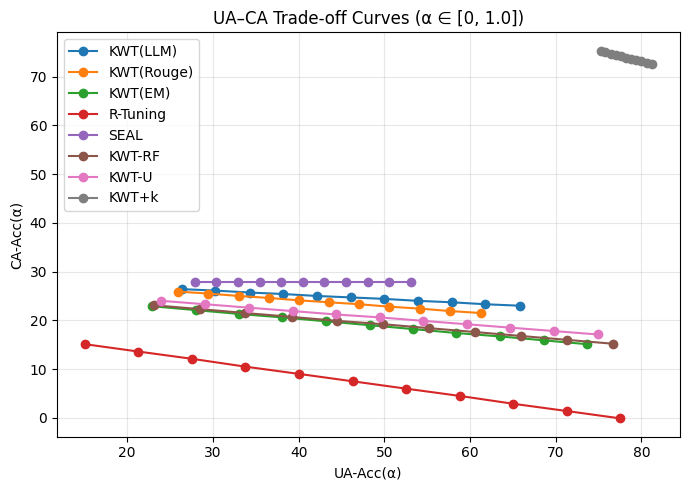

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Full alpha grid from table
# -----------------------------
alphas_all = np.array(
    [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    dtype=float
)

# -----------------------------
# Set alpha_max HERE
# -----------------------------
alpha_max = 1.0   # <-- change this freely (e.g., 0.3, 0.7, 1.0)

# mask for selected alpha range
alpha_mask = alphas_all <= alpha_max
alphas = alphas_all[alpha_mask]

# -----------------------------
# UA / CA values (FULL, aligned with alphas_all)
# -----------------------------
UA_all = {
    "KWT(LLM)":   [26.4, 30.3, 34.3, 38.2, 42.1, 46.1, 50.0, 53.9, 57.9, 61.8, 65.8],
    "KWT(Rouge)": [25.9, 29.4, 33.0, 36.5, 40.0, 43.6, 47.1, 50.6, 54.2, 57.7, 61.3],
    "KWT(EM)":    [22.9, 28.0, 33.1, 38.1, 43.2, 48.3, 53.4, 58.4, 63.5, 68.6, 73.7],
    "R-Tuning":   [15.1, 21.3, 27.6, 33.8, 40.1, 46.3, 52.5, 58.8, 65.0, 71.3, 77.5],
    "SEAL":       [27.9, 30.4, 32.9, 35.5, 38.0, 40.5, 43.0, 45.5, 48.1, 50.6, 53.1],
    "KWT-RF":     [23.1, 28.5, 33.8, 39.2, 44.5, 49.9, 55.2, 60.6, 65.9, 71.3, 76.7],
    "KWT-U":      [24.0, 29.1, 34.2, 39.3, 44.4, 49.5, 54.5, 59.6, 64.7, 69.8, 74.9],
    "KWT+k":      [75.3, 75.8, 76.4, 77.0, 77.6, 78.2, 78.8, 79.4, 80.0, 80.6, 81.2],
}

CA_all = {
    "KWT(LLM)":   [26.4, 26.1, 25.7, 25.4, 25.0, 24.7, 24.4, 24.0, 23.7, 23.3, 23.0],
    "KWT(Rouge)": [25.9, 25.5, 25.0, 24.6, 24.1, 23.7, 23.3, 22.8, 22.4, 21.9, 21.5],
    "KWT(EM)":    [22.9, 22.1, 21.3, 20.6, 19.8, 19.0, 18.2, 17.4, 16.7, 15.9, 15.1],
    "R-Tuning":   [15.1, 13.6, 12.1, 10.5,  9.0,  7.5,  6.0,  4.5,  2.9,  1.4, -0.1],
    "SEAL":       [27.9]*11,
    "KWT-RF":     [23.1, 22.3, 21.5, 20.7, 19.9, 19.2, 18.4, 17.6, 16.8, 16.0, 15.2],
    "KWT-U":      [24.0, 23.3, 22.6, 21.9, 21.2, 20.6, 19.9, 19.2, 18.5, 17.8, 17.1],
    "KWT+k":      [75.3, 75.0, 74.7, 74.4, 74.2, 73.9, 73.6, 73.4, 73.1, 72.8, 72.6],
}

# Slice UA / CA according to alpha_max
UA = {k: np.array(v)[alpha_mask] for k, v in UA_all.items()}
CA = {k: np.array(v)[alpha_mask] for k, v in CA_all.items()}

# -----------------------------
# Trade-off AUC (A안)
# -----------------------------
def tradeoff_auc(ua_vals, ca_vals):
    ua = np.asarray(ua_vals, dtype=float)
    ca = np.asarray(ca_vals, dtype=float)

    d_ua = np.diff(ua)
    tauc = np.sum(0.5 * (ca[:-1] + ca[1:]) * np.abs(d_ua))

    ua_range = np.max(ua) - np.min(ua)
    n_tauc = tauc / ua_range if ua_range > 0 else np.nan
    return tauc, n_tauc, ua_range

# -----------------------------
# Compute results
# -----------------------------
rows = []
for model in UA.keys():
    tauc, n_tauc, ua_range = tradeoff_auc(UA[model], CA[model])
    rows.append({
        "Model": model,
        "alpha_max": alpha_max,
        "TAUC": tauc,
        "UA_range": ua_range,
        "nTAUC": n_tauc,
    })

df = pd.DataFrame(rows).sort_values("nTAUC", ascending=False)
print(df.to_string(index=False))

# -----------------------------
# Plot UA–CA curves
# -----------------------------
plt.figure(figsize=(7, 5))
for model in UA.keys():
    plt.plot(UA[model], CA[model], marker="o", label=model)

plt.xlabel("UA-Acc(α)")
plt.ylabel("CA-Acc(α)")
plt.title(f"UA–CA Trade-off Curves (α ∈ [0, {alpha_max}])")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
